In [99]:
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [100]:
import sys
sys.path.append('ipynb/location/packages')

# Linear program

In [101]:
from ortools.linear_solver import pywraplp


def LinearProgrammingExample():
    """Linear programming sample."""
    solver = pywraplp.Solver.CreateSolver("GLOP")
    if not solver:
        return

    x = solver.NumVar(0, solver.infinity(), "x")
    y = solver.NumVar(0, solver.infinity(), "y")

    solver.Add(x + 2 * y <= 14.0)
    solver.Add(3 * x - y >= 0.0)
    solver.Add(x - y <= 2.0)
    solver.Maximize(3 * x + 4 * y)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print(f"Objective value = {solver.Objective().Value():0.1f}")
        print(f"x = {x.solution_value():0.1f}")
        print(f"y = {y.solution_value():0.1f}")
    else:
        print("The problem does not have an optimal solution.")

LinearProgrammingExample()

Objective value = 34.0
x = 6.0
y = 4.0


In [102]:
from ortools.linear_solver import pywraplp


def LinearProgrammingExample():
    """Linear programming sample."""
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")

    solver.Add(3 * x1 + 6 * x2 + 6 * x3 <= 60)
    solver.Add(x1 + x2 <= 1)
    solver.Add(x2 + x3 <= 1)
    solver.Add(x1 + x3 <= 1)
    solver.Maximize(3 * x1 + 6 * x2 + 6 * x3)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print(f"Objective value = {solver.Objective().Value():0.1f}")
        print(f"x1 = {x1.solution_value():0.1f}")
        print(f"x2 = {x2.solution_value():0.1f}")
        print(f"x3 = {x3.solution_value():0.1f}")
    else:
        print("The problem does not have an optimal solution.")

LinearProgrammingExample()

Objective value = 6.0
x1 = 0.0
x2 = 1.0
x3 = 0.0


# Integer program

In [103]:
import numpy as np

In [104]:
def main():
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")

    solver.Add(3 * x1 + 6 * x2 + 6 * x3 <= 60)
    solver.Add(x1 + x2 <= 1)
    solver.Add(x2 + x3 <= 1)
    solver.Add(x1 + x3 <= 1)
    solver.Maximize(3 * x1 + 6 * x2 + 6 * x3)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Objective value =", solver.Objective().Value())
        print("x1 =", x1.solution_value())
        print("x2 =", x2.solution_value())
        print("x3 =", x3.solution_value())
    else:
        print("The problem does not have an optimal solution.")

if __name__ == "__main__":
    main()

Objective value = 6.0
x1 = 0.0
x2 = 1.0
x3 = 0.0


$$
\max z = 16 x_1 + 22 x_2 + 12 x_3 + 8 x_4
\\
\begin{cases}
5 x_1 + 7 x_2 + 4 x_3 + 3 x_4 \leq 14 \\
x_j = {0, 1}
\end{cases}
$$

In [105]:
def main():
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")
    x4 = solver.IntVar(0.0, infinity, "x4")

    solver.Add(5 * x1 + 7 * x2 + 4 * x3 + 3 * x4 <= 14)
    solver.Add(x1 <= 1)
    solver.Add(x2 <= 1)
    solver.Add(x3 <= 1)
    solver.Add(x4 <= 1)
    solver.Maximize(16 * x1 + 22 * x2 + 12 * x3 + 8 * x4)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Objective value =", solver.Objective().Value())
        print("x1 =", x1.solution_value())
        print("x2 =", x2.solution_value())
        print("x3 =", x3.solution_value())
        print("x4 =", x4.solution_value())
    else:
        print("The problem does not have an optimal solution.")

if __name__ == "__main__":
    main()

Objective value = 42.0
x1 = 0.0
x2 = 1.0
x3 = 1.0
x4 = 1.0


In [106]:
from packages.ortool import data_model

## Plant location

### Balinski model

$$
\min z = \sum_{i,j} c_{ij} x_{ij} + \sum_{i} f_i y_i , \\
\begin{cases}
&\sum_i x_{ij} = 1, \quad &(j=\overline{1,n}) \\
&0 \leq x_{ij} \leq y_i \leq 1, \quad &(i=\overline{1,m}, \: j=\overline{1,n})\\
&y_i={0,1} \quad &(i=\overline{1,m})
\end{cases}
$$

### Model testing

In [107]:
from packages.GraphView import Graph

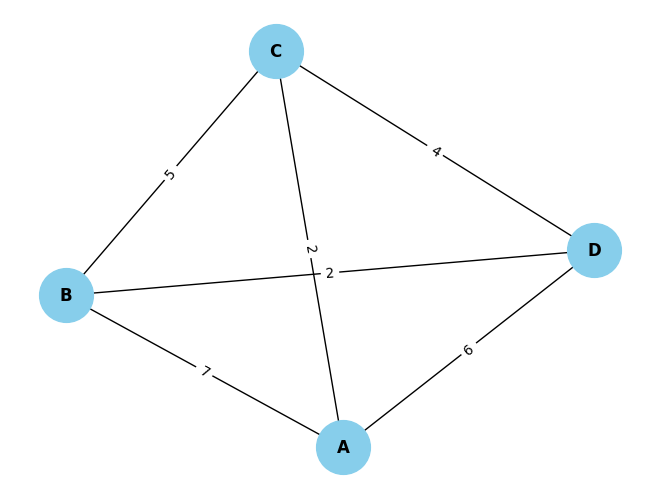

In [108]:
Global = [
    [0, 7, 2, 6],
    [7, 0, 5, 2],
    [2, 5, 0, 4],
    [6, 2, 4, 0]
]
df = Graph(Global)
df.show()

#### Balinski model

$$
\min z = 0x_{11}+7x_{12}+2x_{13}+6x_{14}\\
+7x_{21}+0x_{22}+5x_{23}+2x_{24}\\
+2x_{31}+5x_{32}+0x_{33}+4x_{34}\\
+6x_{41}+2x_{42}+4x_{43}+0x_{44}\\
\\
\\
\\
\begin{cases}
&x_{11}+x_{12}+x_{13}+x_{14}=1\\
&x_{21}+x_{22}+x_{23}+x_{24}=1\\
&x_{31}+x_{32}+x_{33}+x_{34}=1\\
&x_{41}+x_{42}+x_{43}+x_{44}=1\\
\\
&x_{11}+x_{22}+x_{33}+x_{44}=1\\
\\
&x_{21}\le x_{11},\\
&x_{31}\le x_{11},\\
&x_{41}\le x_{11},\\
\\
&x_{12}\le x_{22},\\
&x_{32}\le x_{22},\\
&x_{42}\le x_{22},\\
\\
&x_{13}\le x_{33},\\
&x_{23}\le x_{33},\\
&x_{43}\le x_{33},\\
\\
&x_{14}\le x_{44},\\
&x_{24}\le x_{44},\\
&x_{34}\le x_{44},\\
\\
&x_{11},x_{12},x_{13},x_{14},x_{21},x_{22},x_{23},x_{24},x_{31},x_{32},x_{33},x_{34}\ge 0\\
\end{cases}
$$

##### Python solving

In [109]:
cost_matrix = [[0, 49, 35, 46, 20, 76, 71, 36, 87, 40, 93, 99, 53, 78, 66, 92, 4, 54, 10, 76], [63, 0, 18, 44, 18, 68, 54, 97, 82, 2, 53, 96, 64, 30, 81, 85, 42, 15, 22, 56], [72, 5, 0, 54, 46, 93, 15, 11, 25, 15, 80, 19, 13, 50, 88, 13, 34, 33, 47, 69], [63, 16, 91, 0, 43, 13, 74, 83, 53, 74, 63, 54, 23, 42, 40, 62, 25, 14, 52, 12], [32, 52, 58, 23, 0, 77, 20, 27, 25, 4, 74, 88, 47, 9, 54, 76, 81, 51, 61, 28], [38, 45, 48, 73, 18, 0, 36, 2, 18, 5, 83, 61, 6, 38, 80, 62, 21, 3, 85, 81], [61, 25, 14, 48, 42, 65, 0, 25, 58, 47, 14, 51, 75, 54, 15, 41, 5, 77, 67, 24], [7, 7, 29, 6, 57, 60, 81, 0, 62, 17, 76, 53, 53, 42, 64, 37, 17, 66, 29, 9], [6, 86, 14, 91, 3, 11, 79, 68, 0, 50, 91, 46, 37, 12, 95, 3, 10, 29, 54, 65], [30, 3, 93, 78, 90, 48, 46, 59, 36, 0, 21, 22, 34, 37, 37, 98, 46, 16, 8, 3], [14, 44, 9, 62, 55, 74, 9, 51, 8, 92, 0, 19, 93, 97, 69, 85, 20, 75, 76, 82], [79, 8, 67, 37, 56, 98, 66, 68, 58, 53, 58, 0, 66, 44, 92, 34, 68, 38, 30, 8], [76, 21, 11, 8, 21, 12, 30, 69, 36, 25, 68, 13, 0, 5, 73, 61, 39, 24, 48, 65], [20, 53, 67, 77, 32, 36, 96, 99, 71, 17, 8, 92, 25, 0, 49, 96, 86, 13, 11, 2], [76, 31, 36, 26, 12, 96, 8, 39, 58, 45, 95, 88, 92, 39, 0, 15, 46, 75, 71, 39], [53, 66, 1, 38, 15, 23, 18, 80, 76, 4, 47, 35, 23, 84, 47, 0, 3, 22, 58, 85], [60, 56, 83, 51, 92, 97, 72, 24, 96, 15, 32, 39, 34, 98, 2, 83, 0, 90, 47, 25], [66, 62, 37, 4, 8, 55, 1, 77, 83, 73, 5, 66, 79, 85, 69, 21, 49, 0, 40, 65], [90, 73, 86, 7, 90, 15, 37, 73, 8, 78, 8, 17, 49, 56, 34, 24, 26, 14, 0, 96], [65, 16, 57, 91, 9, 33, 89, 14, 74, 96, 7, 2, 18, 34, 92, 71, 63, 77, 52, 0]]
for row in cost_matrix:
    print(row)

[0, 49, 35, 46, 20, 76, 71, 36, 87, 40, 93, 99, 53, 78, 66, 92, 4, 54, 10, 76]
[63, 0, 18, 44, 18, 68, 54, 97, 82, 2, 53, 96, 64, 30, 81, 85, 42, 15, 22, 56]
[72, 5, 0, 54, 46, 93, 15, 11, 25, 15, 80, 19, 13, 50, 88, 13, 34, 33, 47, 69]
[63, 16, 91, 0, 43, 13, 74, 83, 53, 74, 63, 54, 23, 42, 40, 62, 25, 14, 52, 12]
[32, 52, 58, 23, 0, 77, 20, 27, 25, 4, 74, 88, 47, 9, 54, 76, 81, 51, 61, 28]
[38, 45, 48, 73, 18, 0, 36, 2, 18, 5, 83, 61, 6, 38, 80, 62, 21, 3, 85, 81]
[61, 25, 14, 48, 42, 65, 0, 25, 58, 47, 14, 51, 75, 54, 15, 41, 5, 77, 67, 24]
[7, 7, 29, 6, 57, 60, 81, 0, 62, 17, 76, 53, 53, 42, 64, 37, 17, 66, 29, 9]
[6, 86, 14, 91, 3, 11, 79, 68, 0, 50, 91, 46, 37, 12, 95, 3, 10, 29, 54, 65]
[30, 3, 93, 78, 90, 48, 46, 59, 36, 0, 21, 22, 34, 37, 37, 98, 46, 16, 8, 3]
[14, 44, 9, 62, 55, 74, 9, 51, 8, 92, 0, 19, 93, 97, 69, 85, 20, 75, 76, 82]
[79, 8, 67, 37, 56, 98, 66, 68, 58, 53, 58, 0, 66, 44, 92, 34, 68, 38, 30, 8]
[76, 21, 11, 8, 21, 12, 30, 69, 36, 25, 68, 13, 0, 5, 73, 61, 39,

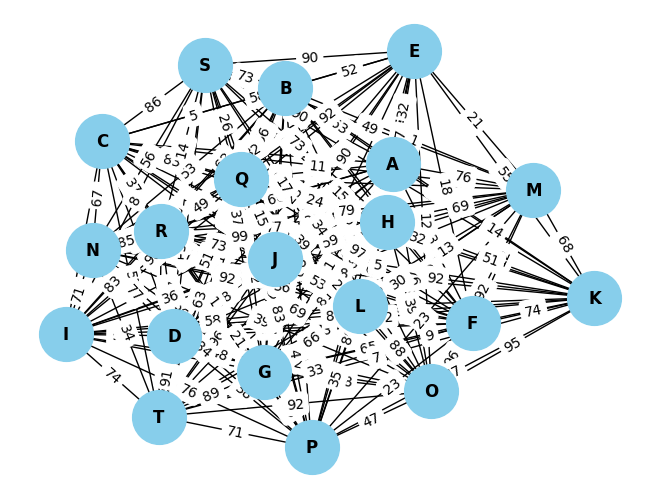

In [110]:
graph = Graph(cost_matrix)
graph.show()

In [111]:
df = data_model(
        cost_matrix=cost_matrix,
        p_facility=10
    )

Detail output

In [112]:
NumVariables, version_solving, obj_val, result, wall_time, iterations, nodes = df.solver(is_maximization=False, is_integer=True)

print(f"Solver Version: {version_solving}")
print(f"Optimal Objective Value: {obj_val}")
for row in result:
    print(row)
print(f"Number of Variables: {NumVariables}")
print(f"Wall Time: {wall_time} ms")
print(f"Iterations: {iterations}")
print(f"Nodes: {nodes}")

Solver Version: CP-SAT solver v9.14.6206
Optimal Objective Value: 32.0
[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0,

# References

- Location Science - Gilbert Laporte, Stefan Nickel - 2019

- COBRA: A New Formulation of the Classic p-Median Location Problem - Richard L. Church - 2003

- The p-Median and its Linear Programming Relaxation: An Approach to Large Problems - K.E. Rosing, C.S. Revelle, H. Rosing-Vogelaar - 1979

- Central facilities location - C. S. ReVelle, R. Swain - 1970